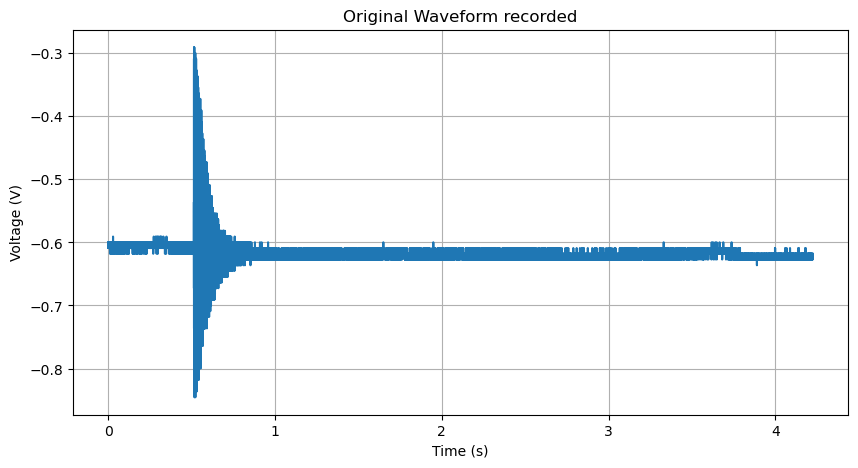

In [1]:
import pandas as pd
import numpy as np
from scipy.signal import find_peaks

# Load the CSV file
filepath = 'Mass1.csv'

# Load the data, skipping the second row which contains units
df = pd.read_csv(filepath, skiprows=[1])

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(df.iloc[:, 0], df.iloc[:, 1])
plt.title("Original Waveform recorded")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.grid(True)
plt.show()

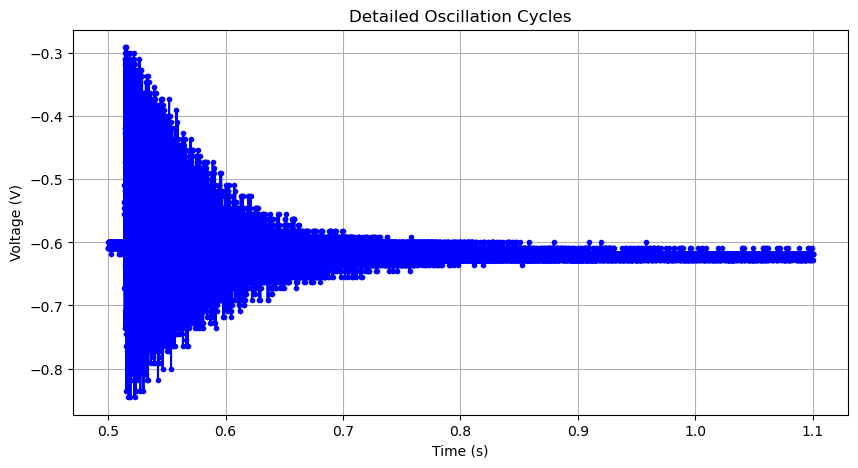

In [2]:
# Extract the actual trigger
df_cycles = df[(df['Time'] >= .5) & (df['Time'] <= 1.1)]

plt.figure(figsize=(10, 5))
plt.plot(df_cycles['Time'], df_cycles['Channel A'], 'b.-')
plt.title("Detailed Oscillation Cycles")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.grid(True)
plt.show()

Number of samples: 5000
Peak index: 1151, Peak frequency: 4604.0000 Hz, Magnitude: 35.8855
Frequency resolution: 4.0000000000004405 Hz
Standard FFT Peak: 4604.0000 Hz
Refined Fitted Peak: 4603.6358 Hz


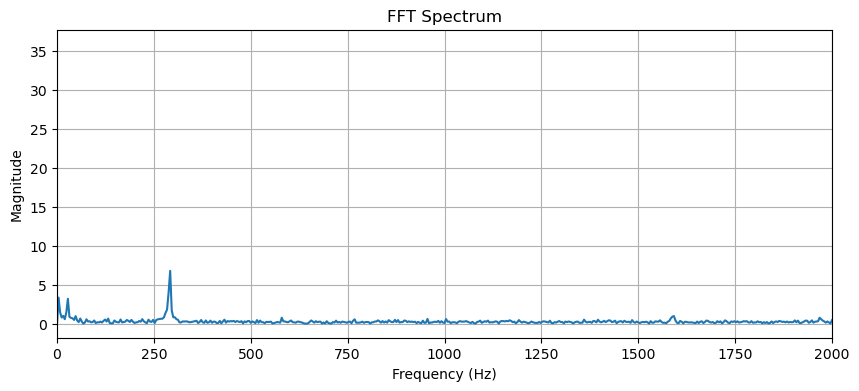

In [3]:
# FFT analysis on waveform from time 0.6 to 1 seconds
df_fft = df[(df['Time'] >= 0.65) & (df['Time'] <= 0.9)]

dt = df_fft['Time'].iloc[1] - df_fft['Time'].iloc[0]
fs = 1.0 / dt

# cancelling offset
y = df_fft['Channel A'].values - np.mean(df_fft['Channel A'].values)

# Performing FFT
n = len(y)
print(f"Number of samples: {n}")
yf = np.fft.rfft(y)
xf = np.fft.rfftfreq(n, d=dt)

# Get peak frequency y(k)
peak_idx = np.argmax(np.abs(yf))

y_k   = np.abs(yf[peak_idx])
y_km1 = np.abs(yf[peak_idx - 1])  # Left bin
y_kp1 = np.abs(yf[peak_idx + 1])  # Right bin

print(f"Peak index: {peak_idx}, Peak frequency: {xf[peak_idx]:.4f} Hz, Magnitude: {y_k:.4f}")

df = xf[1] - xf[0]
print(f"Frequency resolution: {df} Hz")

l_km1 = np.log(y_km1)
l_k   = np.log(y_k)
l_kp1 = np.log(y_kp1)

delta = 0.5 * (l_km1 - l_kp1) / (l_km1 - 2 * l_k + l_kp1)
refined_peak_freq = (peak_idx + delta) * df

print(f"Standard FFT Peak: {xf[peak_idx]:.4f} Hz")
print(f"Refined Fitted Peak: {refined_peak_freq:.4f} Hz")

# Plotting the FFT spectrum 
plt.figure(figsize=(10, 4))
plt.plot(xf, np.abs(yf))
plt.title("FFT Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0, 2000)
plt.grid(True)
plt.show()